In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time

from tqdm import tqdm

import programs.NN as NN
import programs.visualize as vis
import programs.misc as misc
import programs.objects as obj

from programs.PINN import *
from programs.misc import *

In [2]:
torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device='cpu'
if device!='cpu':
    torch.cuda.set_device(device)
print(device)

cuda:0


In [3]:
# Максимальная концентрация проппанта
cmax = 0.65

# Концентрация входящего проппанта в первый момент времени
c1 = 0.25 / cmax

# Концентрация входящего проппанта во второй момент времени
c2 = 0.0 / cmax

c_condition = [c1, c2]

# Интервалы смены концентрации
transitional_times = [0.5]

# Длина интервала перфорации
chi = 0.5

# Степень в вязкости
beta = 0

# Число точек для ГУ (возводится в квадрат)
BC_points = 64

# Число точек для НУ (возводится в квадрат)
IC_points = 64

# Число точек коллокации (возводится в куб)
PDE_points = 32

# Геометрия
L = 1
H = 1
T = 1

In [4]:
data = {'alpha' : L / H,
        'zeta'  : chi / H,
        'kappa' : 1 / L,
        'beta'  : beta,
        'ratio' : 10,
        't_max' : T,
        'times' : transitional_times,
        'c_cond': c_condition,
        'N_PDE' : PDE_points,
        'N_BC'  : BC_points,
        'N_IC'  : IC_points,
        'w_func': 'const',
        'IC_const': 0.0,
        'save_after': True,
        'lr': 1e-5,
        # 'w1': 0,
        # 'w2': 0.5,
        'path' : 'data/basic_models/IC',
        'NN_params' : {'input_size' : 3,
                       'neurons_arr': [48]*6,
                       'output_size' : 3,
                       'depth':5,
                       'act':'Morlet'
                      }
        }

net = Poisson_Convection(data, device=device)
net.model.apply(NN.Net.init_weights)
net.model

Net(
  (fourier_encoder): FourierFeatureEncoder()
  (layers): Sequential(
    (input): Linear(in_features=96, out_features=48, bias=True)
    (input_activation): Morlet()
    (hidden_0): Linear(in_features=48, out_features=48, bias=True)
    (activation_0): Morlet()
    (hidden_1): Linear(in_features=48, out_features=48, bias=True)
    (activation_1): Morlet()
    (hidden_2): Linear(in_features=48, out_features=48, bias=True)
    (activation_2): Morlet()
    (hidden_3): Linear(in_features=48, out_features=48, bias=True)
    (activation_3): Morlet()
    (hidden_4): Linear(in_features=48, out_features=48, bias=True)
    (activation_4): Morlet()
    (output): Linear(in_features=48, out_features=3, bias=True)
  )
)

(tensor(1., device='cuda:0'), tensor(1., device='cuda:0'))

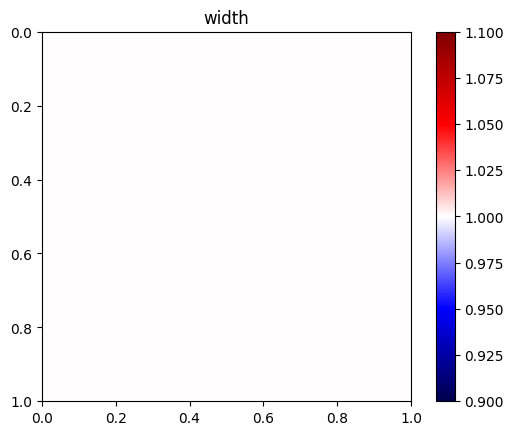

In [5]:
# net.update_width(func_name='elliptic', w=1.5, w1=-1, w2=1.5, w3=0.5, w4=0.5)
x = torch.linspace(0,1,100)
y = torch.linspace(0,1,100)
x, y = torch.meshgrid(x,y, indexing='ij')
plt.imshow(net.w_func(x,y).cpu().T, extent=[0,1,1,0], cmap='seismic')
plt.title('width')
# plt.clim(0,2)
plt.colorbar()
net.w_func(x,y).max(), net.w_func(x,y).min()

In [7]:
net.update_from_file("data/April/3/134950", device=device)
net.path = 'data/April/4'
# net = net.load('data/February/14/52900')
# vars(net)
pass

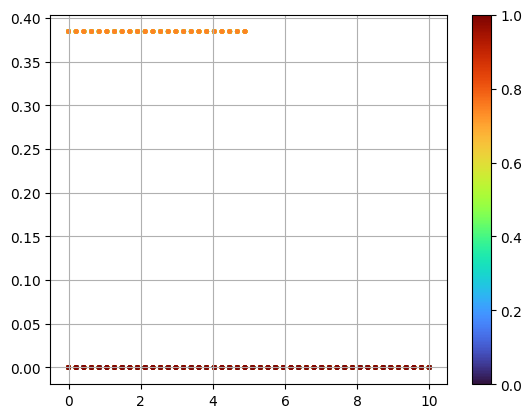

In [8]:
# net.c_cond = [c1, c2, c1, c2]
# net.times = [0.5, 1, 1.5]
# net.t_max = 1.1
net.beta = -0.0
net.make_distributed_points()
plt.grid()
plt.scatter(net.t_BC.data.cpu(), net.c.data.cpu(), c=net.y_BC.data.cpu(), s=6, cmap='turbo')
plt.colorbar()

In [ ]:
# net.weights = [0, 0, 0, 1, 1000, 0, 0, 0]
net.weights =  [1, 1, 1, 1, 1, 1, 0, 0]
# net.weights = [1e-8]*8
# net.weights[3]=1
net.Adam_epochs = 3500
start_time = time.time()
net.max_epoch = 10000
net.max_iter = 1
net.diff = True
# for _ in tqdm(range(100)): net.make_distributed_points()
net.train()
# net.train()
# net.weights = [2, 1, 1.5, 1.5, 1.5, 1, 0, 0]
# for _ in range(100): net.make_distributed_points()
# net.Adam_epochs = net.epoch + 3000
# net.train()
# net.weights = [2.5, 1.5, 1.5, 1.5, 1.5, 1, 0, 0]
# for _ in range(100): net.make_distributed_points()
# net.train()
# net.weights = [3, 1.5, 1.5, 1.5, 1.5, 1, 0, 0]
# for _ in range(100): net.make_distributed_points()
# net.train()
# net.Adam_epochs = net.epoch + 1000
# net.weights = [10, 2, 1.5, 1.5, 1.5, 1, 0, 0]
# for _ in range(100): net.make_distributed_points()
# net.train()
# net.Adam_epochs = net.epoch + 1000
# net.mcx = True
# net.weights = [1000, 2, 1.5, 10, 10, 1, 0, 0]
# net.lr = 0.1
# for _ in range(1):
    # net.Adam_epochs = net.epoch + 3000
    # for _ in tqdm(range(100)): net.make_distributed_points()
    # net.train()
#     net.lr *= 10
# # net.save(f'data/January_8/{net.epoch}')
end_time = time.time()
elapsed_time = end_time - start_time

|     Epochs     |      PDE loss       |     p corr loss     |       IC loss       |       BC loss       |    Summary loss     |      time      |
|       0        |    50749.9453125    |    71929.0859375    |      0.5540193      |    29005.171875     |      151684.75      |    36.2619     |


KeyboardInterrupt: 

: 

In [10]:
net.save(net.path)

In [10]:
net.epoch

138781

In [11]:
net.NN_params['act']         = net.act_dict.get(data.setdefault('NN_params', {1:1}).setdefault('act', None))# 

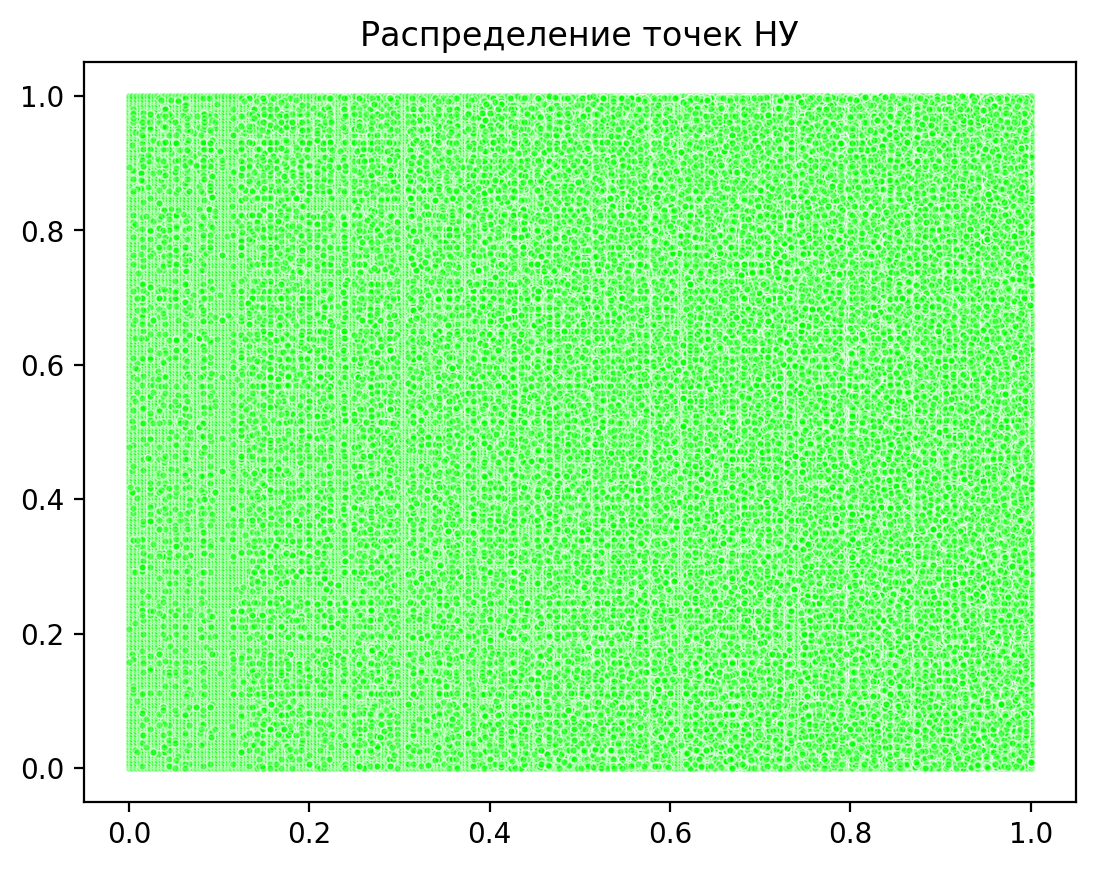

In [12]:
fig = plt.figure(dpi=200)
# err = np.abs(c[0] - np.where(mesh_yx==0, net.c_cond[0], 0)*np.where(np.abs(mesh_xy - H/2)<=chi/2, 1, 0))
# plt.imshow(np.where(err-0>0, err, np.nan), cmap='magma', extent=[0, L, H, 0])
# plt.colorbar()
# plt.gca().invert_yaxis()
plt.scatter(net.x_IC[0*net.N_IC**2:].data.cpu().numpy(), net.y_IC[0*net.N_IC**2:].data.cpu().numpy(), alpha=0.5, c='lime', edgecolors='white', s=7, linewidths=0.5)
plt.title('Распределение точек НУ')
pass

In [11]:
try:
    print('Elapsed time: ', elapsed_time)
except NameError: pass

Elapsed time:  661.3734974861145
